In [4]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

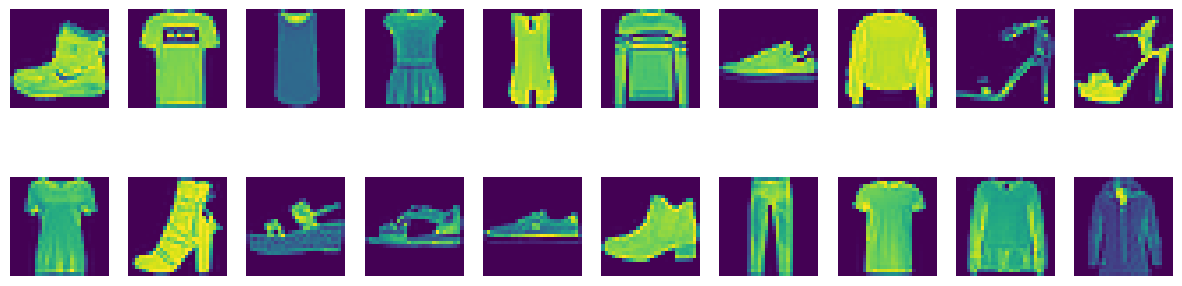

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
for i in range(20):
    plt.subplot(2, 10, (i + 1))
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

In [ ]:
# 28x28 이미지 0~255사이의 숫자로되어 있음
x_train[0]

In [ ]:
 # minmax 0~1 스케일링
# 이미지는 minmax 스케일링이 좋다 왜냐하면 음수값이 없고 편차가 줄어들기 때문
x_train1 = x_train / 255.0
x_test1 = x_test / 255.0

In [11]:
# (n, 28, 28) => (n, 784)
x_train2 = x_train1.reshape(-1, 28*28)
x_test2 = x_test1.reshape(-1, 28*28)
x_train2.shape, x_test2.shape

((60000, 784), (10000, 784))

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=10, random_state=123)
model.fit(x_train2)

-317234.7998590564

In [14]:
model.labels_

array([7, 0, 5, ..., 0, 5, 5], shape=(60000,), dtype=int32)

In [16]:
pred = model.predict(x_test2)
pred

array([3, 4, 6, ..., 2, 6, 5], shape=(10000,), dtype=int32)

In [26]:
# 0~9 사이의 숫자로 분류한것 중에 0에 해당하는 것의 위치만 pred_0에 보관
import numpy as np
pred_0 = np.where(pred==0)[0]
pred_0

array([  19,   27,   29, ..., 9957, 9958, 9980], shape=(1258,))

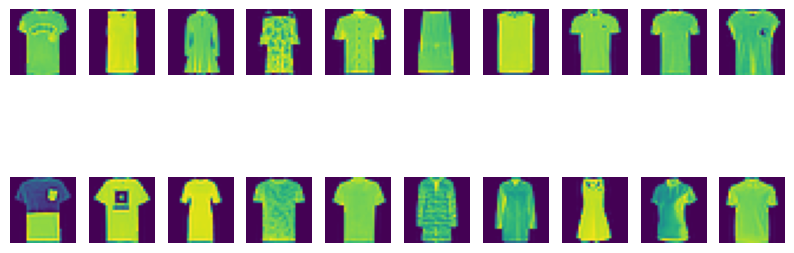

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(20):
    plt.subplot(2, 10, (i+1))
    plt.imshow(x_test[pred_0[i]])
    plt.axis('off')

plt.show()

In [32]:
np.unique(pred, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32),
 array([1258, 1080, 1271,  755, 1611, 1265, 1476,  471,  386,  427]))

In [ ]:
x_test11 = x_test / 255.0
x_test12 = x_test / 255
x_test11.dtype, x_test12.dtype

(dtype('float64'), dtype('float64'))